--- Starting Grouped Bar Chart: Differences vs SARIMA Baseline ---
Found 18 scenario IDs
Group 'Baseline scenarios (No income effect)': 3 scenarios
Group 'Uniform population + Income dynamics': 3 scenarios
Group 'Randomized population + Income dynamics': 3 scenarios
Group 'Environmentalist target + Income dynamics': 3 scenarios
Group 'Wasteful target + Income dynamics': 3 scenarios
Group 'Uniform population + Randomized Income': 3 scenarios



Success! Grouped bar chart saved at: ..\figuras\figure-barplot-diferencas-grupos-vs-sarima.pdf


Also saved as PNG: ..\figuras\figure-barplot-diferencas-grupos-vs-sarima.png

DETAILED DIFFERENCES BY YEAR (in k m³ vs SARIMA Baseline)
  Year    Baseline (No income       Uniform population   Randomized population        Environmentalist                Wasteful    Uniform population +
--------------------------------------------------------------------------------------------------------------------------------------------------------
  2026     -53.1k     -52.0k     -52.2k     -54.1k     -53.2k     -56.5k
  2027     -49.9k     -30.6k     -30.7k     -47.8k     -40.2k     -52.5k
  2028     -47.0k      -5.3k      -5.4k     -40.4k     -24.7k     -48.8k
  2029     -44.4k      +0.1k      +0.0k     -38.7k     -21.5k     -44.9k
  2030     -42.1k     +14.4k     +14.3k     -34.5k     -12.8k     -41.2k
  2031     -40.1k     +27.9k     +27.8k     -30.5k      -4.6k     -37.1k
  2032     -38.5k     +52.3k     +52.2k     -23.4k     +10.3k     -34.8k
  2033     -37.3k     +60.3k     +60.2k     -21.1

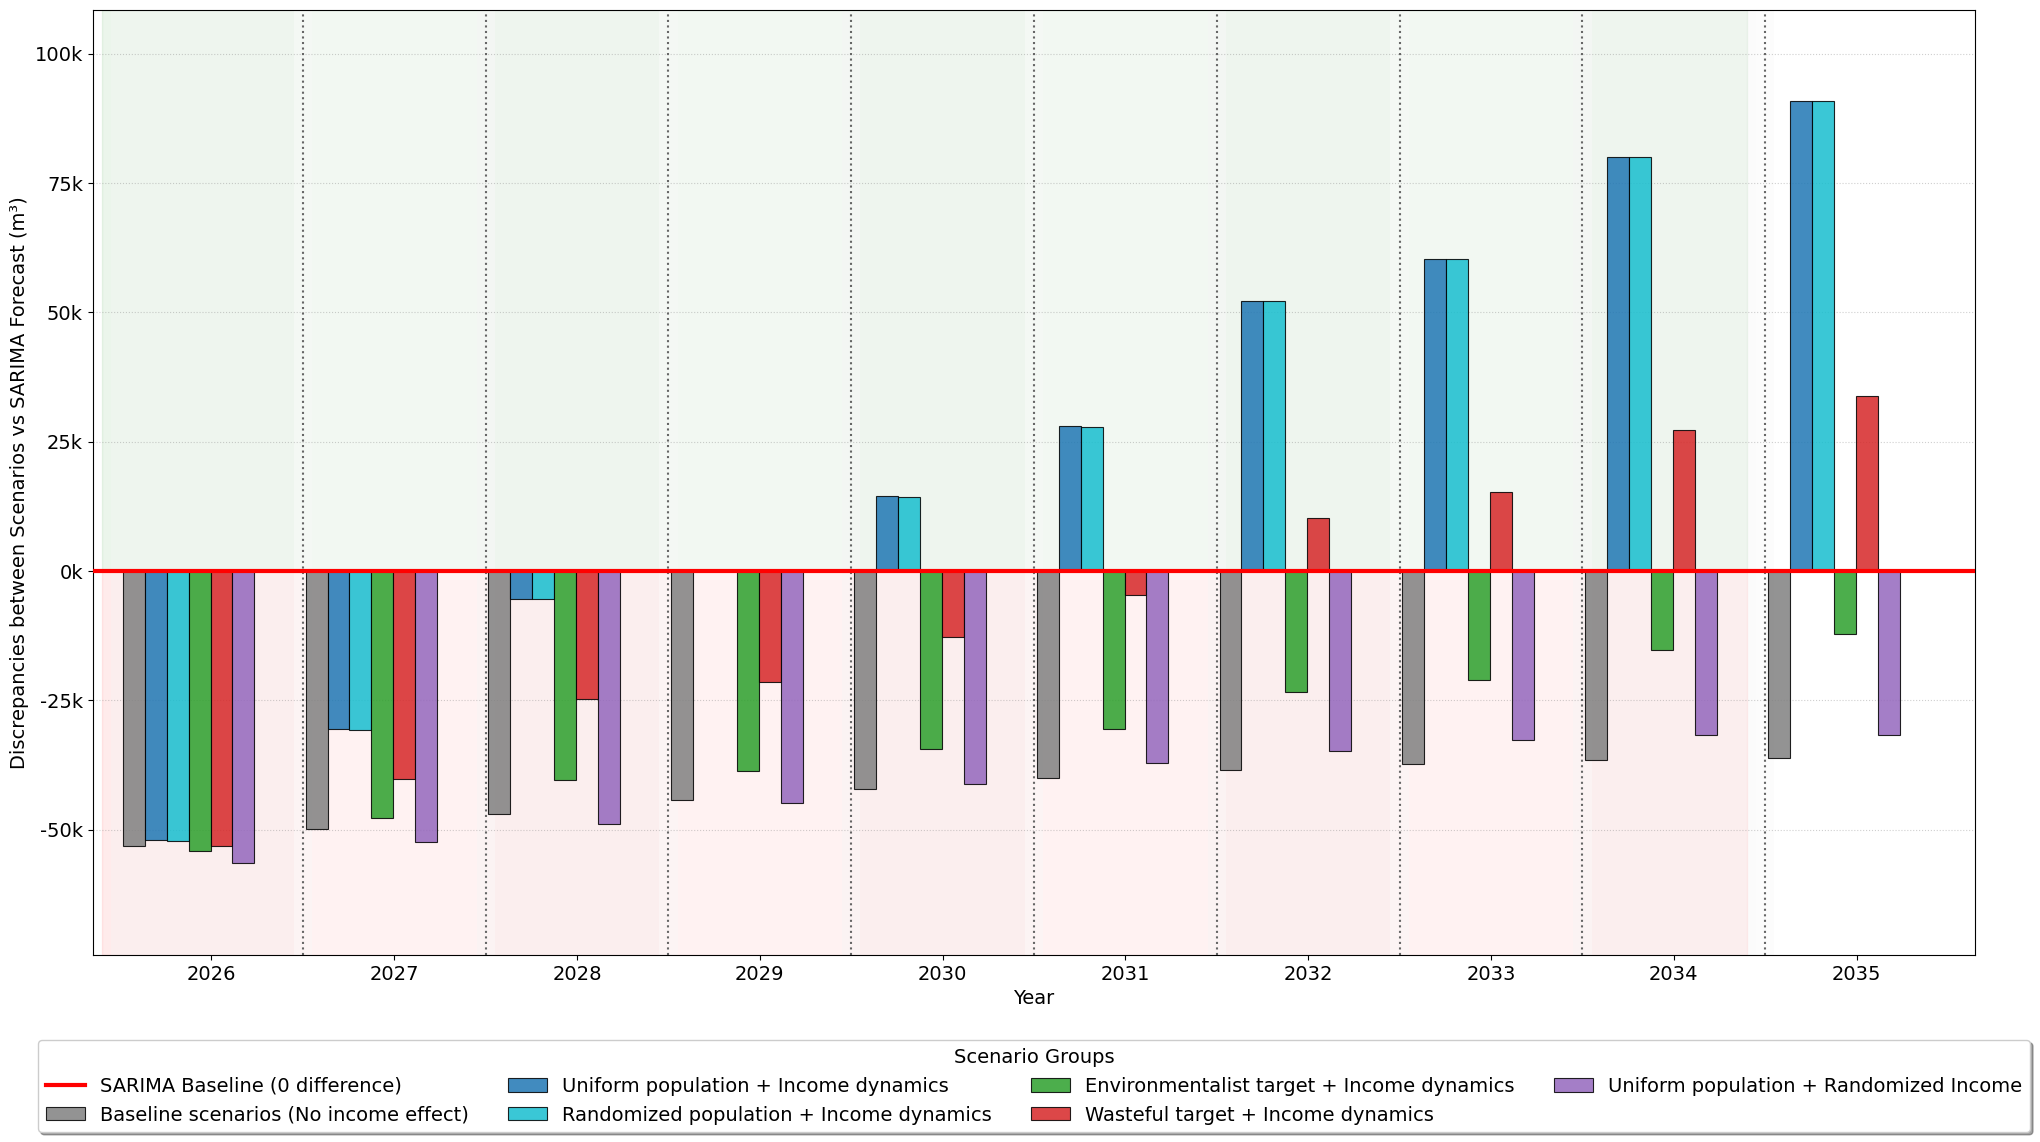

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import os
import re

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = '..'

np.random.seed(42)

SCENARIO_FILE = 'consumo_previsto_todos_cenarios_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

OUTPUT_FILENAME = 'figure-barplot-diferencas-grupos-vs-sarima.pdf'

FIGURE_WIDTH = 22
FIGURE_HEIGHT = 12

INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def extract_scenario_id(col_name):
    """Extract the scenario ID from column name (e.g., 'CI_Pop_Uniforme' -> 'CI')"""
    match = re.match(r'^(C[IVX]+)', col_name)
    if match:
        return match.group(1)
    return col_name

def main():
    print("--- Starting Grouped Bar Chart: Differences vs SARIMA Baseline ---")

    # Load Scenarios
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    if not os.path.exists(path_scenarios):
        print(f"Error: Scenarios file not found: {path_scenarios}")
        return

    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    
    # Filter to desired period
    df_scenarios = df_scenarios[(df_scenarios['Date'] >= '2026-01-01') & (df_scenarios['Date'] <= '2035-12-31')]
    
    # Get all scenario columns
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    
    # Extract scenario IDs from column names
    scenario_id_map = {}
    for col in scenario_cols:
        scenario_id = extract_scenario_id(col)
        scenario_id_map[col] = scenario_id
    
    # Define group mappings
    group_mappings = {
        'Baseline scenarios (No income effect)': {
            'scenarios': ['CI', 'CII', 'CIII'],
            'color': '#808080',
            'legend_label': 'Baseline scenarios (No income effect)'
        },
        'Uniform population + Income dynamics': {
            'scenarios': ['CIV', 'CV', 'CVI'],
            'color': '#1f77b4',
            'legend_label': 'Uniform population + Income dynamics'
        },
        'Randomized population + Income dynamics': {
            'scenarios': ['CVII', 'CVIII', 'CIX'],
            'color': '#17becf',
            'legend_label': 'Randomized population + Income dynamics'
        },
        'Environmentalist target + Income dynamics': {
            'scenarios': ['CX', 'CXI', 'CXII'],
            'color': '#2ca02c',
            'legend_label': 'Environmentalist target + Income dynamics'
        },
        'Wasteful target + Income dynamics': {
            'scenarios': ['CXIII', 'CXIV', 'CXV'],
            'color': '#d62728',
            'legend_label': 'Wasteful target + Income dynamics'
        },
        'Uniform population + Randomized Income': {
            'scenarios': ['CXVI', 'CXVII', 'CXVIII'],
            'color': '#9467bd',
            'legend_label': 'Uniform population + Randomized Income'
        }
    }
    
    # Group columns by scenario ID
    columns_by_scenario = {}
    for col in scenario_cols:
        scenario_id = scenario_id_map[col]
        if scenario_id not in columns_by_scenario:
            columns_by_scenario[scenario_id] = []
        columns_by_scenario[scenario_id].append(col)
    
    print(f"Found {len(columns_by_scenario)} scenario IDs")

    # Load SARIMA
    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    if not os.path.exists(path_sarima):
        print(f"Error: SARIMA file not found: {path_sarima}")
        return
        
    df_sarima = pd.read_csv(path_sarima)
    df_sarima = df_sarima.rename(columns={'Date': 'Date', 'Projected_Consumption': 'SARIMA'})
    df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    df_sarima = df_sarima[(df_sarima['Date'] >= '2026-01-01') & (df_sarima['Date'] <= '2035-12-31')]

    # Calculate annual totals
    df_combined = df_scenarios.copy()
    df_combined = pd.merge(df_combined, df_sarima[['Date', 'SARIMA']], on='Date', how='left')
    
    all_cols = scenario_cols + ['SARIMA']
    df_annual = sum_yearly(df_combined, 'Date', all_cols)
    
    years = df_annual['Year'].values
    
    # Calculate differences in m³ for each scenario
    scenario_diff_data = {}
    
    for scenario_id, columns in columns_by_scenario.items():
        yearly_diffs = []
        for year in years:
            year_values = []
            for col in columns:
                scenario_value = df_annual[df_annual['Year'] == year][col].values[0]
                sarima_value = df_annual[df_annual['Year'] == year]['SARIMA'].values[0]
                diff = scenario_value - sarima_value
                year_values.append(diff)
            yearly_diffs.append(np.mean(year_values))
        scenario_diff_data[scenario_id] = yearly_diffs
    
    # Group by scenario group
    group_annual_diffs = {}
    group_order = []
    
    for group_name, group_info in group_mappings.items():
        scenarios_in_group = [s for s in group_info['scenarios'] if s in scenario_diff_data]
        
        if scenarios_in_group:
            group_yearly_avg = []
            for year_idx in range(len(years)):
                year_values = [scenario_diff_data[s][year_idx] for s in scenarios_in_group]
                group_yearly_avg.append(np.mean(year_values))
            group_annual_diffs[group_name] = group_yearly_avg
            group_order.append(group_name)
            print(f"Group '{group_name}': {len(scenarios_in_group)} scenarios")
    
    # ==========================================
    # Create Grouped Bar Chart
    # ==========================================
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    
    n_groups = len(group_order)
    n_years = len(years)
    
    # Bar settings
    bar_width = 0.12
    gap_between_years = 0.25
    
    # Year centers
    year_centers = np.arange(n_years)
    
    # Get y-limits first to define the fill areas
    all_diffs = []
    for diffs in group_annual_diffs.values():
        all_diffs.extend(diffs)
    y_max_all = max(all_diffs)
    y_min_all = min(all_diffs)
    y_range = y_max_all - y_min_all
    y_margin = y_range * 0.12
    
    # === FUNDO VERMELHO E VERDE EM TODA EXTENSÃO ===
    # Área acima do baseline (positiva) - VERDE
    ax.fill_between(year_centers - 0.6, 0, y_max_all + y_margin, 
                    alpha=0.08, color='green', label='_nolegend_', zorder=0)
    
    # Área abaixo do baseline (negativa) - VERMELHO
    ax.fill_between(year_centers - 0.6, y_min_all - y_margin, 0, 
                    alpha=0.08, color='red', label='_nolegend_', zorder=0)
    
    # === EFEITO ZEBRADO ===
    zebra_colors = ['#f5f5f5', '#ffffff']
    
    for i, year in enumerate(years):
        x_start = i - 0.55
        x_end = i + 0.55
        color = zebra_colors[i % 2]
        ax.axvspan(x_start, x_end, alpha=0.4, facecolor=color, zorder=1, edgecolor='none')
    
    # === LINHA PONTILHADA MAIS FORTE NA DIVISÃO DOS ANOS ===
    for i in range(1, n_years):
        ax.axvline(x=i - 0.5, color='#666666', linestyle=':', alpha=1.0, linewidth=1.5, zorder=2)
    
    # Posições iniciais para as barras
    total_bar_width = n_groups * bar_width + gap_between_years
    year_start_positions = year_centers - total_bar_width / 2 + bar_width / 2
    
    # Plot bars
    for i, group_name in enumerate(group_order):
        yearly_diffs = group_annual_diffs[group_name]
        bar_positions = year_start_positions + i * bar_width
        group_color = group_mappings[group_name]['color']
        
        bars = ax.bar(bar_positions, yearly_diffs, bar_width, 
                     label=group_mappings[group_name]['legend_label'],
                     color=group_color,
                     alpha=0.85, edgecolor='black', linewidth=0.8, zorder=5)
    
    # Zero line (SARIMA baseline) - mais grossa e visível
    ax.axhline(y=0, color='red', linestyle='-', linewidth=3, alpha=1.0, 
               label='SARIMA Baseline (0 difference)', zorder=10)
    
    # X-axis configuration
    ax.set_xticks(year_centers)
    ax.set_xticklabels(years.astype(int), fontsize=14)
    ax.set_xlabel('Year', fontsize=14)
    
    # Y-axis configuration
    ax.set_ylabel('Discrepancies between Scenarios vs SARIMA Forecast (m³)', fontsize=14)

    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    # Set font size for y-axis tick labels
    for label in ax.get_yticklabels():
        label.set_fontsize(14)
    
    # Set limits
    ax.set_ylim(y_min_all - y_margin, y_max_all + y_margin)
    ax.set_xlim(-0.65, n_years - 0.35)
    
    # Grid
    ax.grid(True, axis='y', linestyle=':', alpha=0.4, zorder=3, color='#888888')
    
    # Title
    #plt.title('Annual Consumption Differences by Scenario Group (2026-2035)\n(Group Average vs SARIMA Baseline)', 
    #          fontsize=16, fontweight='bold', pad=25)
    
    # Legend with ncol=4
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), 
              fontsize=14, frameon=True, shadow=True, ncol=4, 
              title='Scenario Groups', title_fontsize=14)
    
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    
    # Save
    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)
    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"\nSuccess! Grouped bar chart saved at: {full_output_path}")
    
    # Save as PNG
    png_path = full_output_path.replace('.pdf', '.png')
    plt.savefig(png_path, format='png', bbox_inches='tight', dpi=150)
    print(f"Also saved as PNG: {png_path}")
    
    # Print summary table
    print("\n" + "="*100)
    print("DETAILED DIFFERENCES BY YEAR (in k m³ vs SARIMA Baseline)")
    print("="*100)
    
    # Header
    header = f"{'Year':>6}"
    for group_name in group_order:
        short = group_mappings[group_name]['legend_label'].replace(' scenarios', '').replace(' + Income dynamics', '').replace(' target', '')
        if len(short) > 22:
            short = short[:20]
        header += f"  {short:>22}"
    print(header)
    print("-" * (8 + 24 * len(group_order)))
    
    # Data rows
    for i, year in enumerate(years):
        row = f"{year:>6}"
        for group_name in group_order:
            val = group_annual_diffs[group_name][i] / 1000
            row += f"  {val:>+8.1f}k"
        print(row)
    
    # Additional statistics
    print("\n" + "="*100)
    print("10-YEAR SUMMARY STATISTICS")
    print("="*100)
    for group_name in group_order:
        diffs = group_annual_diffs[group_name]
        mean_diff = np.mean(diffs) / 1000
        total_diff = np.sum(diffs) / 1000
        short_name = group_mappings[group_name]['legend_label']
        print(f"{short_name:>40}: Mean = {mean_diff:+8.1f}k m³/year | Total 10-year = {total_diff:+8.1f}k m³")
    
    plt.show()

if __name__ == "__main__":
    main()